# Parameter Performance Evaluation

Evaluates how well the model works as a function of the 35 CAMELS cosmological/astrophysical
parameters, using the held-out test simulations from:
- Preprocessed patches: `/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/test`
- Raw simulations: `/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/`

Metrics per patch:
- Mass error: median |relative error| per channel
- Power spectrum error: median |log10(P_gen / P_true)| per channel

These are correlated against the 35 input parameters and halo mass.

In [1]:
import sys, os
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from scipy.stats import pearsonr

from data import load_file_list, AstroDataset, NormStats
from train import FlowMatchingLit
from metrics import batch_power_spectra, CHANNEL_NAMES

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Device: cuda


## Configuration

In [2]:
DATA_ROOT   = '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu'
RUN_DIR     = Path('/mnt/home/mlee1/ceph/fm_runs/fm_base')
CKPT_PATH   = RUN_DIR / 'checkpoints' / 'last.ckpt'

SB35_PARAMS = '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/CosmoAstroSeed_IllustrisTNG_L50n512_SB35.txt'

BATCH_SIZE  = 64
N_STEPS     = 50
N_WORKERS   = 8

PARAM_NAMES = [
    'Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor',
    'VariableWindVelFactor', 'RadioFeedbackReiorientationFactor', 'OmegaBaryon',
    'HubbleParam', 'n_s', 'MaxSfrTimescale', 'FactorForSofterEQS', 'IMFslope',
    'SNII_MinMass_Msun', 'ThermalWindFraction', 'VariableWindSpecMomentum',
    'WindFreeTravelDensFac', 'MinWindVel', 'WindEnergyReductionFactor',
    'WindEnergyReductionMetallicity', 'WindEnergyReductionExponent', 'WindDumpFactor',
    'SeedBlackHoleMass', 'BlackHoleAccretionFactor', 'BlackHoleEddingtonFactor',
    'BlackHoleFeedbackFactor', 'BlackHoleRadiativeEfficiency', 'QuasarThreshold',
    'QuasarThresholdPower', 'UVBH0beta', 'UVBH0Deltaz', 'UVBHepbeta', 'UVBHepDeltaz',
    'SNIa_Rate_Norm', 'SNIa_Rate_DTD_power', 'SofteningComovingType01',
]

## Load model and generate predictions on full test set

In [3]:
norm_stats = NormStats.load(RUN_DIR / 'norm_stats.npz')
print(f'Stellar norm: mean={norm_stats.target_mean[2]:.4f}, std={norm_stats.target_std[2]:.4f}')

model = FlowMatchingLit.load_from_checkpoint(CKPT_PATH, map_location=device)
model.eval()
model.to(device)
print(f'Loaded checkpoint from epoch {torch.load(CKPT_PATH, map_location="cpu")["epoch"]}')

Stellar norm: mean=1.5461, std=2.9502


/tmp/ipykernel_305055/217836173.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  print(f'Loaded checkpoint from epoch {torch.load(CKPT_PATH, map_location="cpu")["epoch"]}

Loaded checkpoint from epoch 55


In [5]:
all_test_files = load_file_list(DATA_ROOT, 'test')
print(f'Total test patches available: {len(all_test_files)}')

# Evaluate on a random subset for faster iteration
N_SUBSET = 100
SUBSET_SEED = 42
rng = np.random.RandomState(SUBSET_SEED)
subset_idx = rng.choice(len(all_test_files), size=min(N_SUBSET, len(all_test_files)), replace=False)
test_files = [all_test_files[i] for i in subset_idx]
print(f'Using random subset: {len(test_files)} patches (seed={SUBSET_SEED})')

ds = AstroDataset(test_files, norm_stats)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=N_WORKERS, pin_memory=True, persistent_workers=True)

fm = model.fm

all_real, all_gen, all_params_raw, all_halo_mass = [], [], [], []

with torch.no_grad():
    for i, batch in enumerate(tqdm(loader, desc='Generating')):
        cond   = batch['condition'].to(device)
        ls     = batch['large_scale'].to(device)
        params = batch['params'].to(device)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            gen = fm.sample(cond, ls, params, n_steps=N_STEPS)

        real_np = batch['target'].numpy()
        gen_np  = gen.float().cpu().numpy()

        # Denormalize to physical space
        for arr in (real_np, gen_np):
            for ch in range(3):
                arr[:, ch] = arr[:, ch] * norm_stats.target_std[ch] + norm_stats.target_mean[ch]
                arr[:, ch] = 10.0 ** arr[:, ch] - 1.0
        real_np = np.clip(real_np, 0, None)
        gen_np  = np.clip(gen_np,  0, None)

        all_real.append(real_np)
        all_gen.append(gen_np)

        # Load raw (physical) params for this batch from the subset npz files
        start = i * BATCH_SIZE
        for j in range(len(real_np)):
            d = np.load(test_files[start + j])
            all_params_raw.append(d['params'].astype(np.float32))
            all_halo_mass.append(float(d['halo_mass']))

real       = np.concatenate(all_real)           # (N, 3, 128, 128)
gen        = np.concatenate(all_gen)            # (N, 3, 128, 128)
params_raw = np.stack(all_params_raw)           # (N, 35)
halo_mass  = np.array(all_halo_mass)            # (N,)
print(f'Generated {len(real)} patches')

Total test patches available: 42720
Using random subset: 100 patches (seed=42)


Generating:   0%|          | 0/2 [00:00<?, ?it/s]

Generated 100 patches


## Compute per-patch errors

In [6]:
# Per-patch mass relative error and P(k) error for each channel
mass_rel_err = np.zeros((len(real), 3))   # (N, 3)
pk_log_err   = np.zeros((len(real), 3))   # (N, 3)

for ch in range(3):
    m_r = real[:, ch].sum(axis=(-2, -1))
    m_g = gen[:, ch].sum(axis=(-2, -1))
    mass_rel_err[:, ch] = (m_g - m_r) / (m_r + 1e-30)

    # P(k) error: log10 ratio averaged over k modes
    for i in range(len(real)):
        _, pk_r, _ = batch_power_spectra(real[i:i+1, ch])
        _, pk_g, _ = batch_power_spectra(gen[i:i+1, ch])
        ratio = pk_g / (pk_r + 1e-30)
        pk_log_err[i, ch] = float(np.mean(np.abs(np.log10(ratio + 1e-30))))

mass_abs_err = np.abs(mass_rel_err) * 100.0  # percentage

print('Mean mass |rel err| per channel [%]:', mass_abs_err.mean(axis=0).round(2))
print('Mean P(k) |log10 ratio| per channel:', pk_log_err.mean(axis=0).round(4))

Mean mass |rel err| per channel [%]: [ 0.55  1.87 30.4 ]
Mean P(k) |log10 ratio| per channel: [0.0789 0.2034 0.3363]


## Pearson correlation: parameters vs errors

In [7]:
# Compute Pearson r between each parameter and each error metric
n_params = params_raw.shape[1]
corr_mass = np.zeros((n_params, 3))  # (35, 3-channels)
corr_pk   = np.zeros((n_params, 3))

for p in range(n_params):
    for ch in range(3):
        corr_mass[p, ch], _ = pearsonr(params_raw[:, p], mass_abs_err[:, ch])
        corr_pk[p, ch],   _ = pearsonr(params_raw[:, p], pk_log_err[:, ch])

# Also correlate with halo mass
corr_halo_mass = np.zeros((3, 2))  # (3-channels, mass-err/pk-err)
for ch in range(3):
    corr_halo_mass[ch, 0], _ = pearsonr(np.log10(halo_mass + 1e-30), mass_abs_err[:, ch])
    corr_halo_mass[ch, 1], _ = pearsonr(np.log10(halo_mass + 1e-30), pk_log_err[:, ch])
print('Halo mass correlation (mass_err, pk_err) per channel:')
for ch in range(3):
    print(f'  {CHANNEL_NAMES[ch]}: r={corr_halo_mass[ch, 0]:.3f} (mass), r={corr_halo_mass[ch, 1]:.3f} (pk)')

Halo mass correlation (mass_err, pk_err) per channel:
  DM_hydro: r=0.118 (mass), r=0.192 (pk)
  Gas: r=-0.045 (mass), r=0.167 (pk)
  Stars: r=-0.049 (mass), r=0.174 (pk)


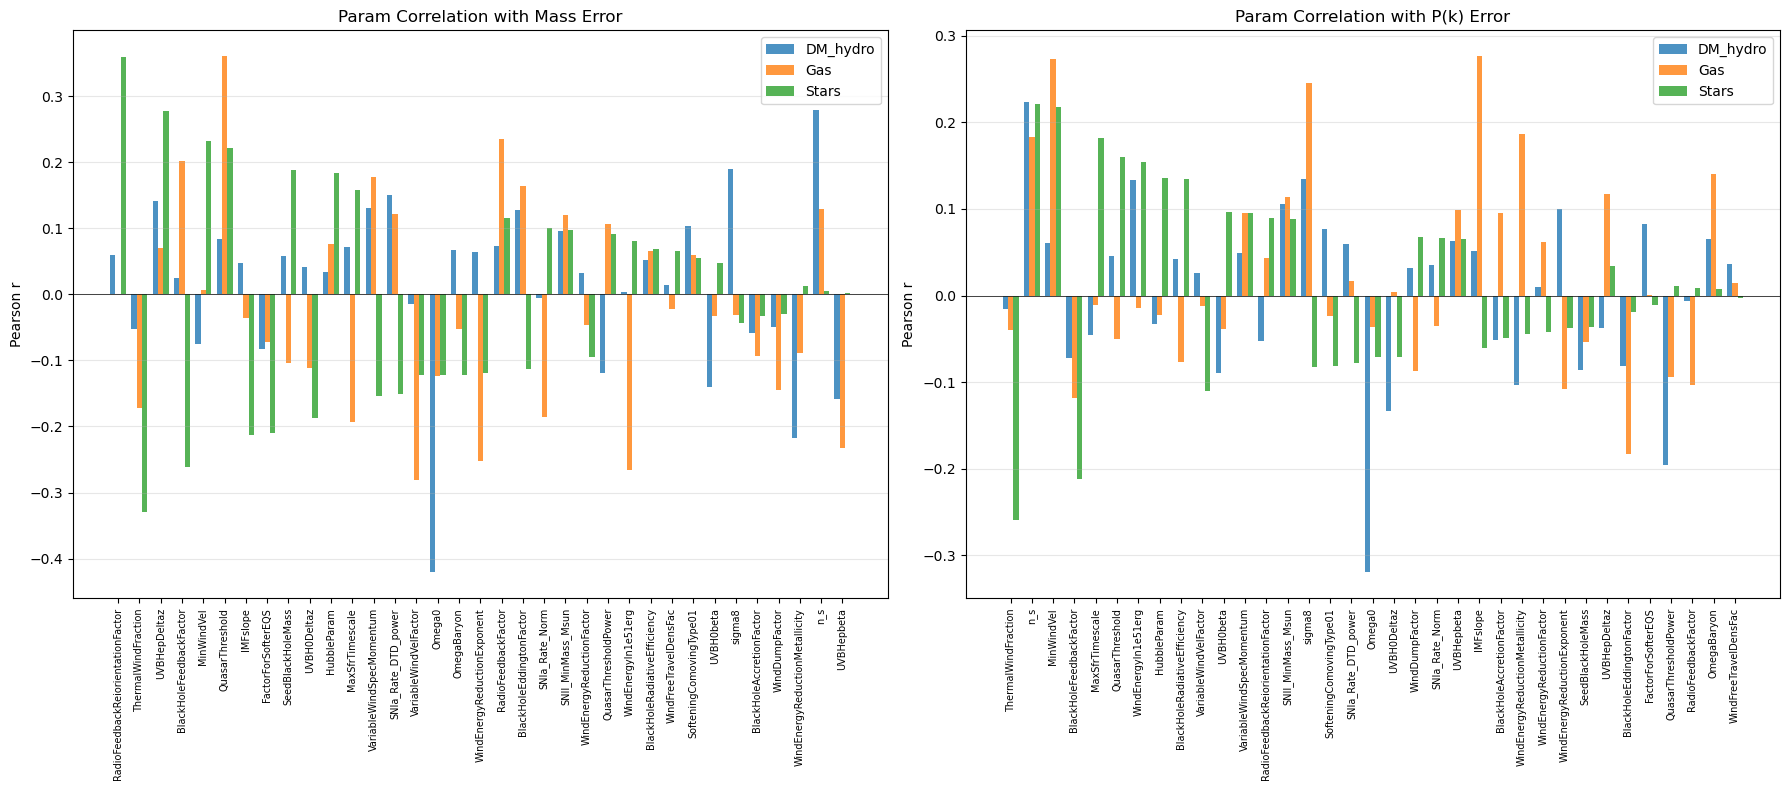

In [8]:
# Plot: Pearson r for all params, sorted by |r| for stellar channel
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, corr_mat, title in [
    (axes[0], corr_mass, 'Mass Error'),
    (axes[1], corr_pk,   'P(k) Error'),
]:
    # Sort by |r| for stellar channel
    order = np.argsort(np.abs(corr_mat[:, 2]))[::-1]
    x = np.arange(n_params)
    width = 0.25
    for i, (name, ch) in enumerate(zip(CHANNEL_NAMES, range(3))):
        ax.bar(x + i * width, corr_mat[order, ch], width, label=name, alpha=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([PARAM_NAMES[o] for o in order], rotation=90, fontsize=7)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_ylabel('Pearson r')
    ax.set_title(f'Param Correlation with {title}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Top-5 parameter scatter plots

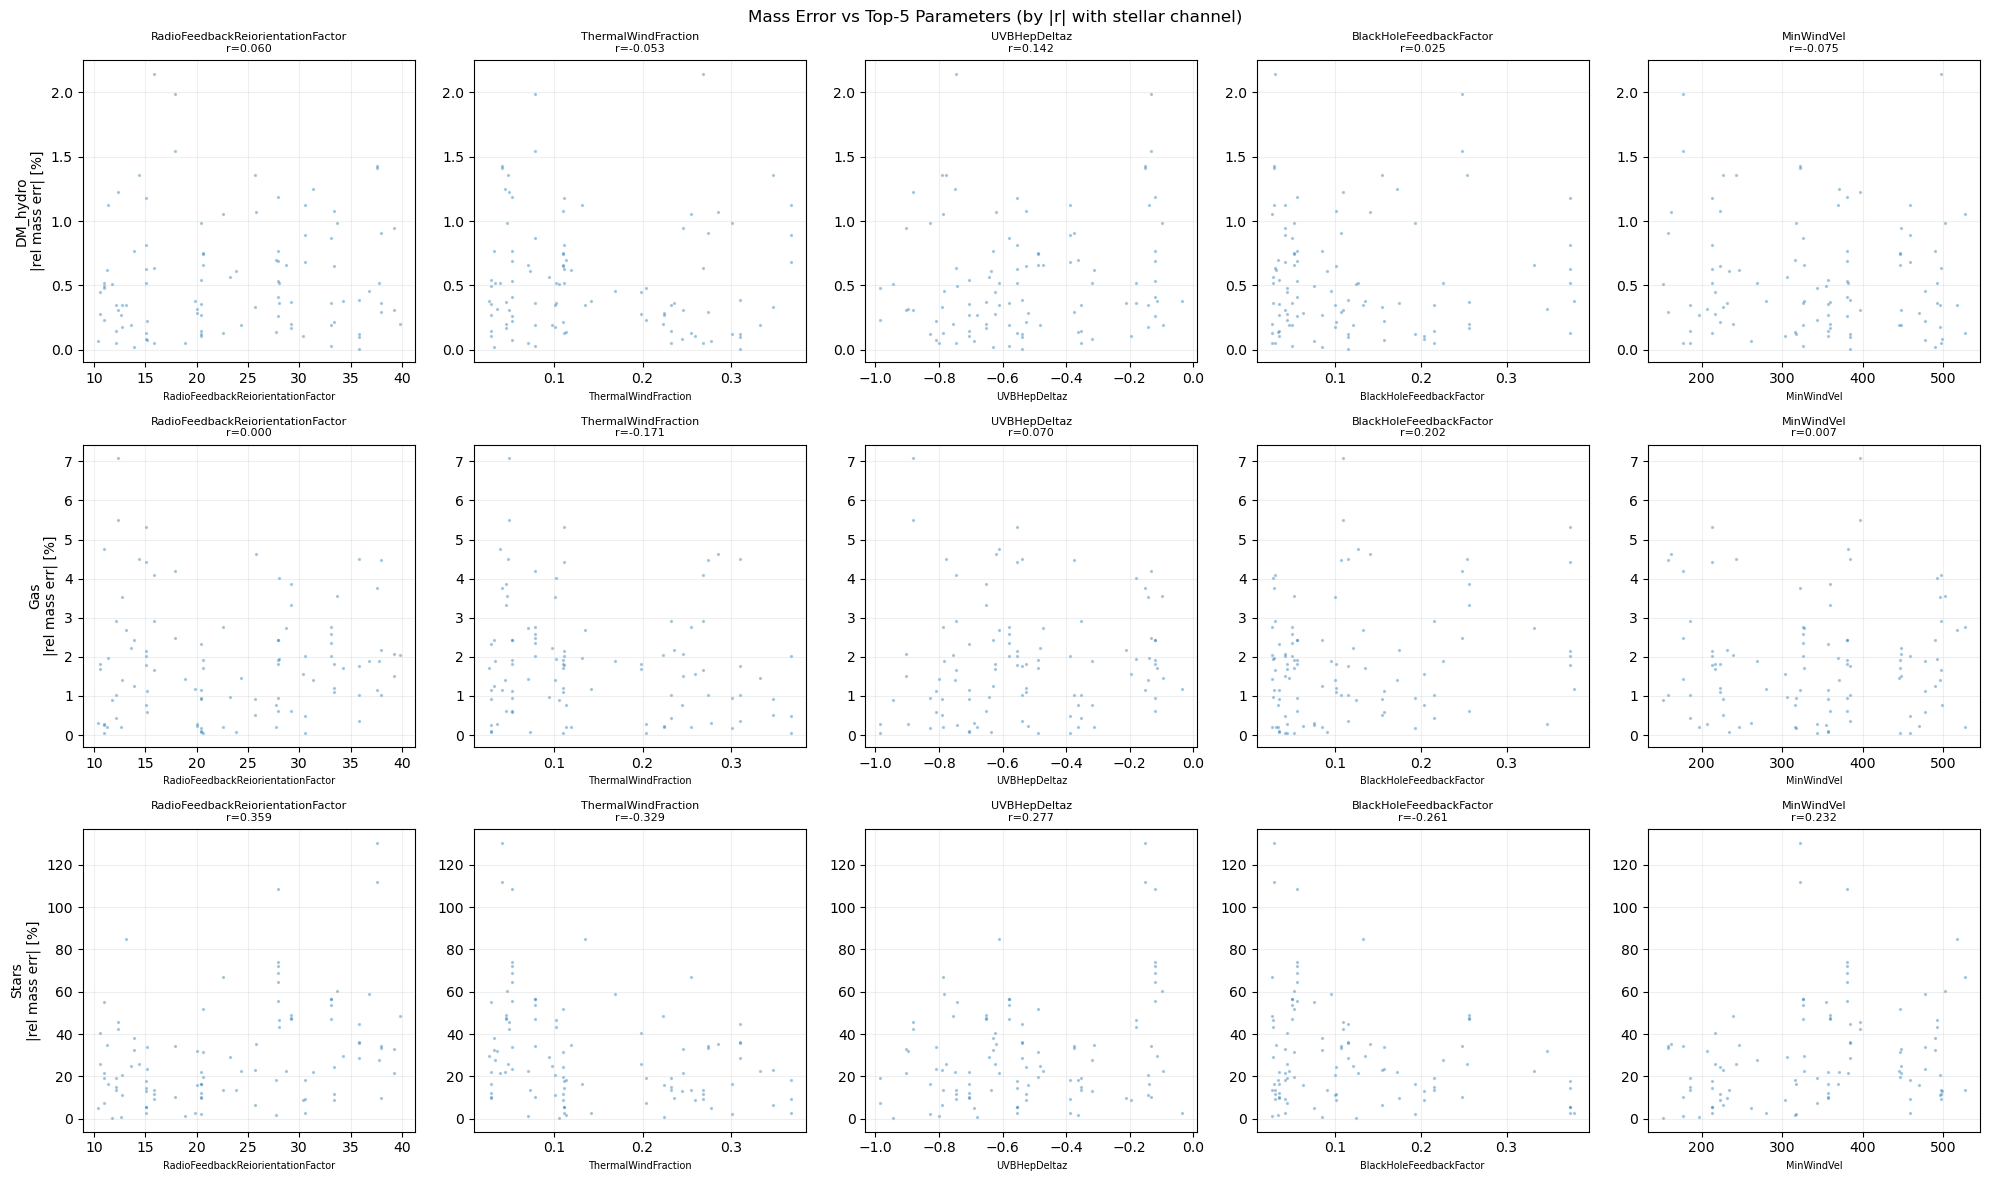

In [9]:
# Top 5 params by |r| with stellar mass error
top5_idx = np.argsort(np.abs(corr_mass[:, 2]))[::-1][:5]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for col, p_idx in enumerate(top5_idx):
    for ch in range(3):
        ax = axes[ch, col]
        x = params_raw[:, p_idx]
        y = mass_abs_err[:, ch]
        ax.scatter(x, y, s=2, alpha=0.3, rasterized=True)
        r = corr_mass[p_idx, ch]
        ax.set_title(f'{PARAM_NAMES[p_idx]}\nr={r:.3f}', fontsize=8)
        ax.set_xlabel(PARAM_NAMES[p_idx], fontsize=7)
        if col == 0:
            ax.set_ylabel(f'{CHANNEL_NAMES[ch]}\n|rel mass err| [%]')
        ax.grid(True, alpha=0.2)

plt.suptitle('Mass Error vs Top-5 Parameters (by |r| with stellar channel)', fontsize=12)
plt.tight_layout()
plt.show()

## 2D error map: Omega_m vs sigma_8

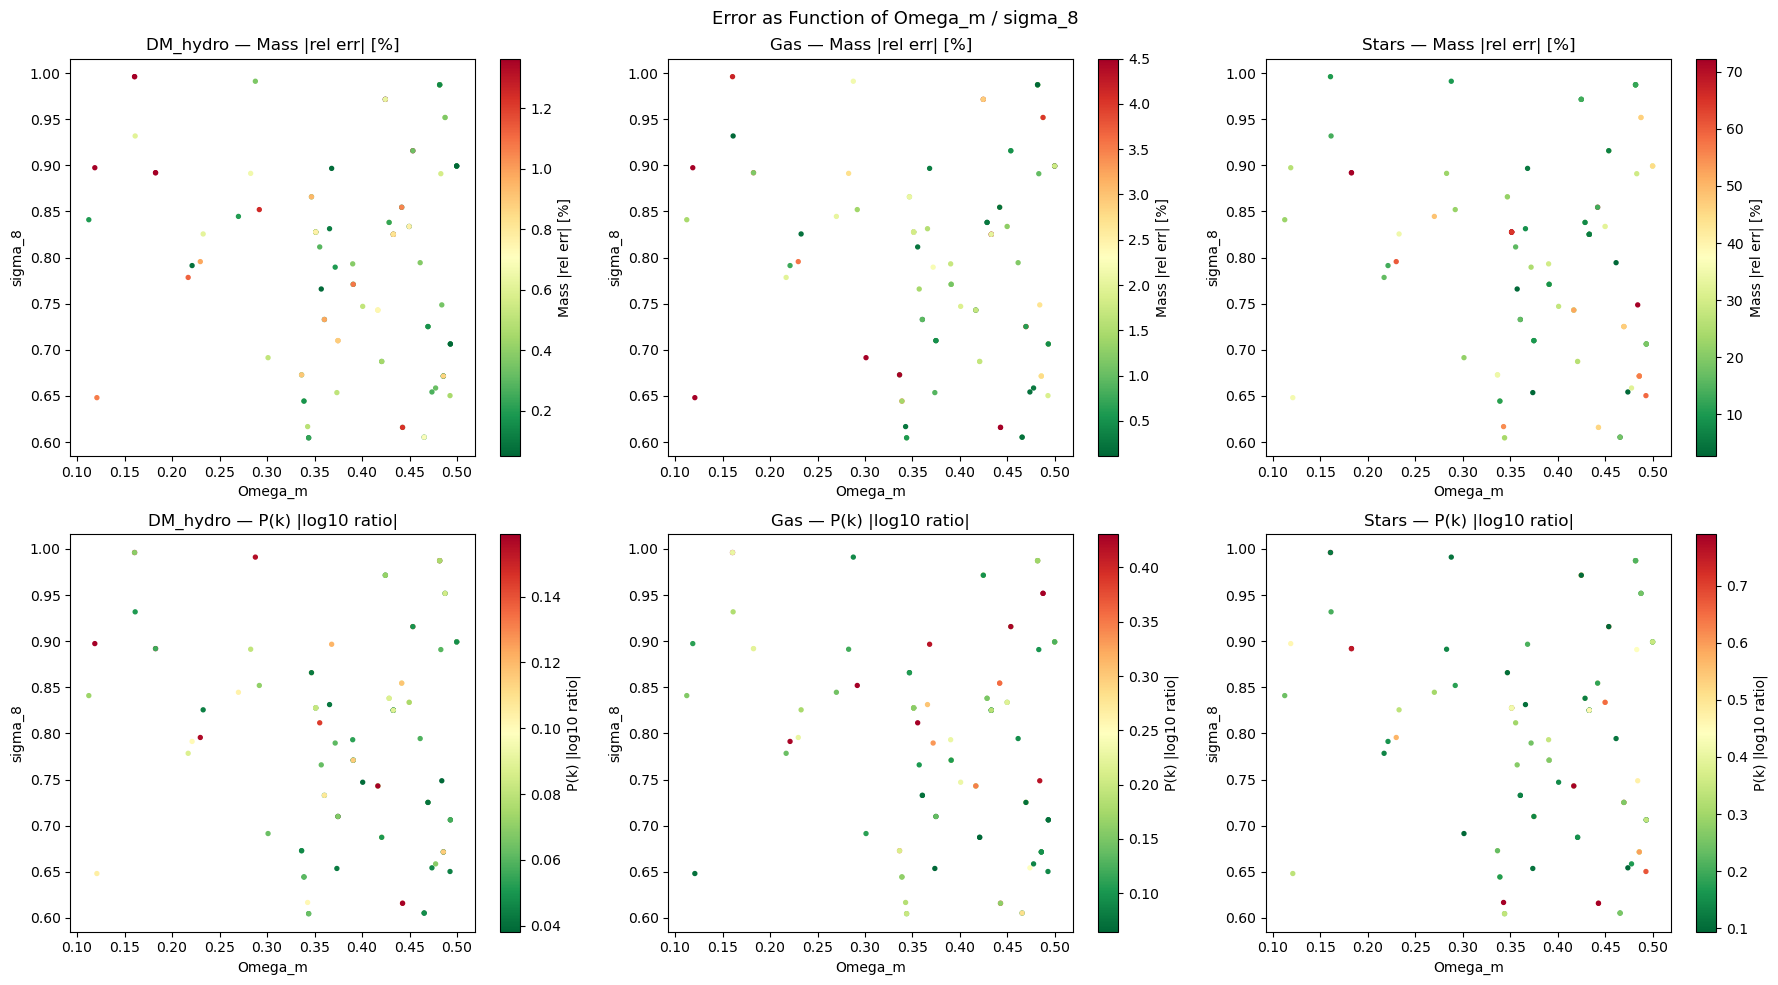

In [10]:
omega_m_idx = PARAM_NAMES.index('Omega0')
sigma8_idx  = PARAM_NAMES.index('sigma8')

omega_m = params_raw[:, omega_m_idx]
sigma8  = params_raw[:, sigma8_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ch in range(3):
    for row, (err, err_name) in enumerate([
        (mass_abs_err[:, ch], 'Mass |rel err| [%]'),
        (pk_log_err[:, ch],   'P(k) |log10 ratio|'),
    ]):
        ax = axes[row, ch]
        sc = ax.scatter(omega_m, sigma8, c=err, s=8, cmap='RdYlGn_r',
                        vmin=np.percentile(err, 5), vmax=np.percentile(err, 95),
                        rasterized=True)
        plt.colorbar(sc, ax=ax, label=err_name)
        ax.set_xlabel('Omega_m')
        ax.set_ylabel('sigma_8')
        ax.set_title(f'{CHANNEL_NAMES[ch]} — {err_name}')

plt.suptitle('Error as Function of Omega_m / sigma_8', fontsize=13)
plt.tight_layout()
plt.show()

## Error vs halo mass

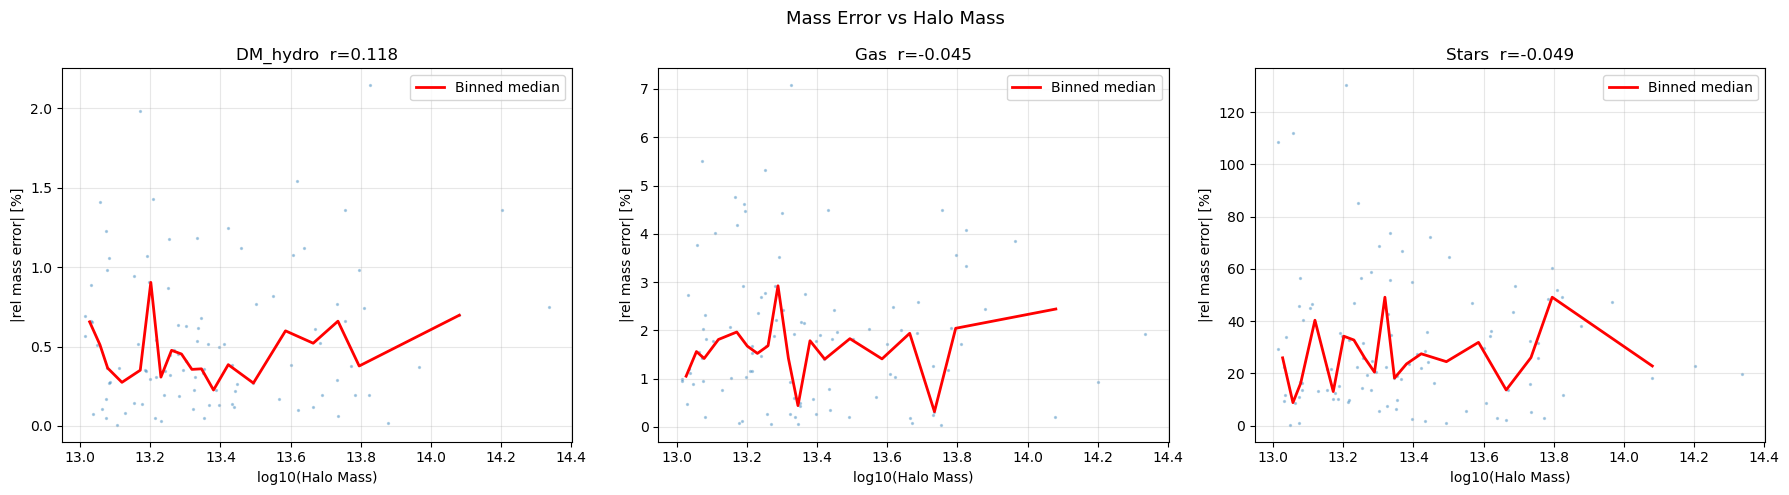

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

log_mass = np.log10(halo_mass + 1e-30)

for ch in range(3):
    ax = axes[ch]
    ax.scatter(log_mass, mass_abs_err[:, ch], s=2, alpha=0.3, rasterized=True)

    # Binned median
    bins = np.percentile(log_mass, np.linspace(0, 100, 20))
    bin_idx = np.digitize(log_mass, bins)
    bin_med = [np.median(mass_abs_err[bin_idx == b, ch]) for b in range(1, len(bins))]
    bin_cen = 0.5 * (bins[:-1] + bins[1:])
    ax.plot(bin_cen, bin_med, 'r-', linewidth=2, label='Binned median')

    r = corr_halo_mass[ch, 0]
    ax.set_xlabel('log10(Halo Mass)')
    ax.set_ylabel('|rel mass error| [%]')
    ax.set_title(f'{CHANNEL_NAMES[ch]}  r={r:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Mass Error vs Halo Mass', fontsize=13)
plt.tight_layout()
plt.show()

## Summary table

In [12]:
print('=== Top 10 Parameters by |Pearson r| with Stellar Mass Error ===')
top10 = np.argsort(np.abs(corr_mass[:, 2]))[::-1][:10]
print(f'{"Parameter":<35} {"r(DM)":>8} {"r(Gas)":>8} {"r(Stars)":>9}')
print('-' * 62)
for p in top10:
    print(f'{PARAM_NAMES[p]:<35} {corr_mass[p,0]:+8.3f} {corr_mass[p,1]:+8.3f} {corr_mass[p,2]:+9.3f}')

print()
print('=== Top 10 Parameters by |Pearson r| with Stellar P(k) Error ===')
top10_pk = np.argsort(np.abs(corr_pk[:, 2]))[::-1][:10]
print(f'{"Parameter":<35} {"r(DM)":>8} {"r(Gas)":>8} {"r(Stars)":>9}')
print('-' * 62)
for p in top10_pk:
    print(f'{PARAM_NAMES[p]:<35} {corr_pk[p,0]:+8.3f} {corr_pk[p,1]:+8.3f} {corr_pk[p,2]:+9.3f}')

=== Top 10 Parameters by |Pearson r| with Stellar Mass Error ===
Parameter                              r(DM)   r(Gas)  r(Stars)
--------------------------------------------------------------
RadioFeedbackReiorientationFactor     +0.060   +0.000    +0.359
ThermalWindFraction                   -0.053   -0.171    -0.329
UVBHepDeltaz                          +0.142   +0.070    +0.277
BlackHoleFeedbackFactor               +0.025   +0.202    -0.261
MinWindVel                            -0.075   +0.007    +0.232
QuasarThreshold                       +0.084   +0.361    +0.222
IMFslope                              +0.048   -0.036    -0.213
FactorForSofterEQS                    -0.083   -0.072    -0.209
SeedBlackHoleMass                     +0.057   -0.104    +0.188
UVBH0Deltaz                           +0.041   -0.111    -0.187

=== Top 10 Parameters by |Pearson r| with Stellar P(k) Error ===
Parameter                              r(DM)   r(Gas)  r(Stars)
--------------------------------------